## Image Recognition Before Deep Learning

Before Convolutional Neural Networks (CNNs) took over around 2012, image recognition relied on a **manual, multi-step pipeline**:

1. **Preprocessing** — reduce noise and irrelevant detail (e.g. Gaussian blur)
2. **Segmentation** — split the image into meaningful regions using algorithms like K-Means, watershed, or graph-cuts
3. **Hand-crafted feature extraction** — engineers manually designed descriptors to capture what was "interesting":
   - **Color histograms** — distribution of RGB values across a region
   - **HOG** (Histogram of Oriented Gradients) — encodes edge directions and shapes
   - **SIFT / SURF** — scale and rotation-invariant keypoint descriptors
   - **Gabor filters** — texture features based on frequency and orientation
4. **Classical classifier** — the features were fed into an SVM, Random Forest, or similar model to produce a prediction

### The core limitation

All features were *manually designed* — humans had to decide what mattered for each task. This was brittle, task-specific, and hard to scale.

**CNNs solved this** by *learning* which features are useful directly from raw pixel data, replacing the entire hand-crafted pipeline with a single end-to-end trainable model.

---

<br>

*This notebook walks through the classical approach first (filtering → K-Means segmentation → feature extraction), then moves on to a practical Deep Neural Network example.*

<br>


# Image Processing

## Load Data

In [1]:
#!pip install sk-video
#!pip install Pillow

#from google. colab import files
#uploaded = files. upload()

<class 'numpy.ndarray'>
(333, 500, 3)


array([[ 69,  71,  72, ..., 116, 114, 115],
       [ 67,  68,  69, ..., 117, 116, 115],
       [ 67,  67,  66, ..., 121, 119, 120],
       ...,
       [ 99,  96,  95, ...,  74,  72,  70],
       [ 94,  95,  95, ...,  75,  74,  74],
       [ 92,  94,  94, ...,  72,  71,  70]], dtype=uint8)

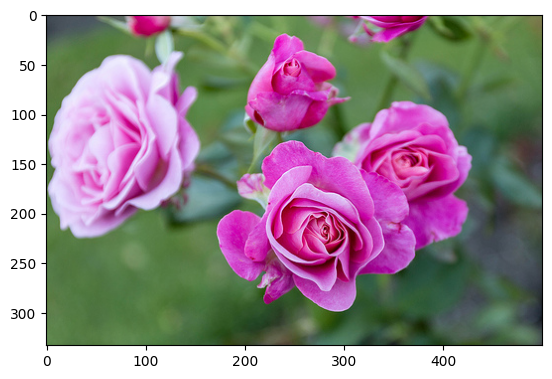

In [2]:
from PIL import Image
from numpy import asarray
from matplotlib import image
from matplotlib import pyplot

# load the image
image = Image.open('data/Flowers for image classification.png')

# convert image to numpy array
data = asarray(image)
print(type(data))

# summarize shape
print(data.shape)

display(data[:,:,0])

# display the array of pixels as an image
pyplot.imshow(data)
pyplot.show()

## Use entire range of data?

In [3]:
print("R ranges between ", data[:,:,0].max(), data[:,:,0].min())
print("B ranges between ", data[:,:,1].max(), data[:,:,1].min())
print("G ranges between ", data[:,:,2].max(), data[:,:,2].min())

R ranges between  255 9
B ranges between  249 0
G ranges between  255 0


## Filtering

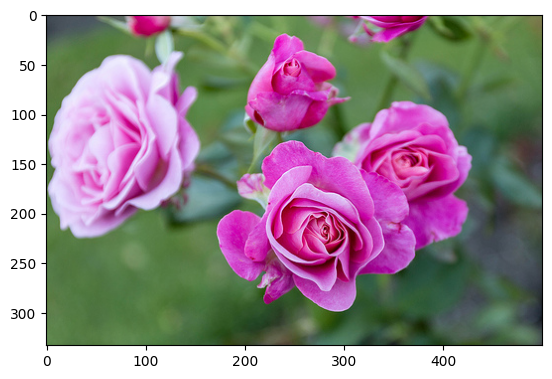

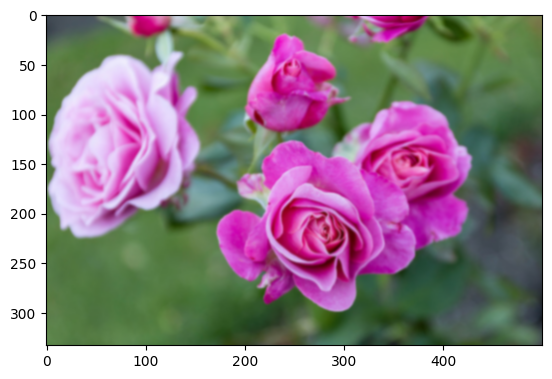

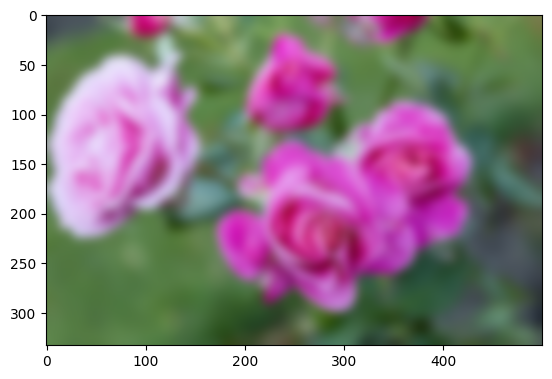

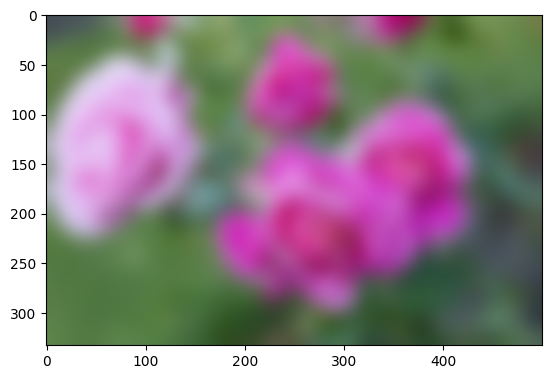

In [28]:
# Apply Gaussian smoothing with different sigma values to blur the image,
# then display the filtered result for each level of smoothing.
#
# "sigma" controls the amount of blur (higher sigma = more smoothing).
#

from scipy.ndimage import gaussian_filter

sigmas = [0, 1, 5, 10]
for std in sigmas:
  data_filtered = gaussian_filter(data, sigma=std)

  for c in [0,1,2]:
    data_filtered[:,:,c] = gaussian_filter(data[:,:,c], sigma=std)

  pyplot.imshow(data_filtered)
  pyplot.show()

## K-Means: flower vs not flower

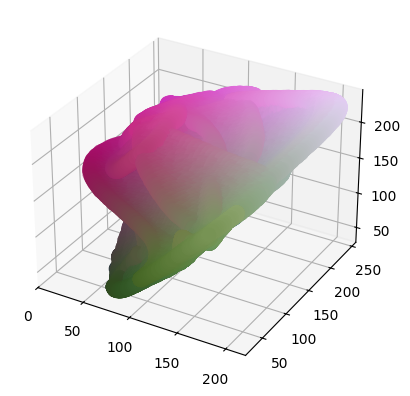

In [33]:
# Convert the image into a list of RGB pixels, then plot each pixel in a 3D graph
# where the x-, y-, and z-axes represent the Red, Green, and Blue colour values.

from matplotlib import pyplot as plt

# Reshape the image into a list where each row represents one pixel's RGB values.
pixel_array = data_filtered.reshape(data.shape[0]*data.shape[1], 3) 
# display(pixel_array)

# Create a new 3D figure for plotting the pixel colours.
fig = plt.figure()
ax = plt.axes(projection='3d')


# Separate the Red, Green, and Blue values to use as the x-, y-, and z-coordinates.
zdata = pixel_array[:, 0]
xdata = pixel_array[:, 1]
ydata = pixel_array[:, 2]
# display(pixel_array)

# Plot each pixel as a point in 3D RGB colour space using its original colour.
ax.scatter3D(xdata, ydata, zdata, s=100, facecolor=pixel_array/255);

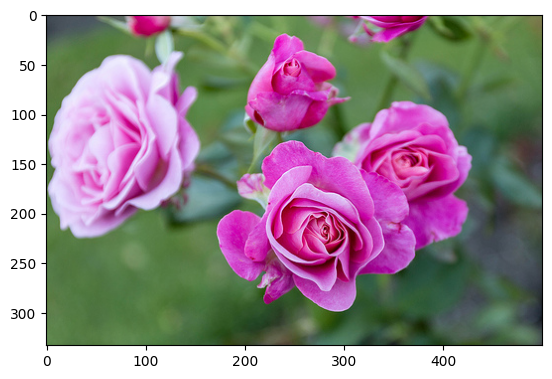

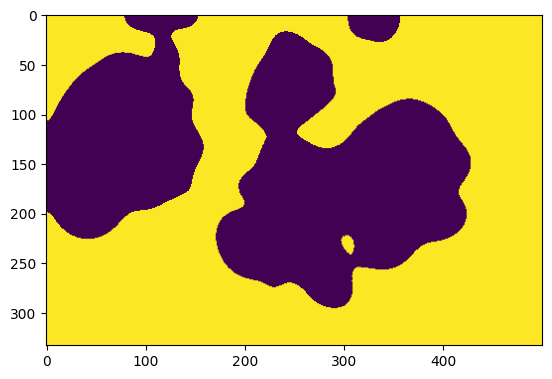

In [36]:
# Clustering by the color only
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0).fit(pixel_array)
data_labels = kmeans.labels_
data_labels.shape

data_labels = data_labels.reshape(data.shape[0], data.shape[1])
data_labels.shape

pyplot.imshow(data)
pyplot.show()

pyplot.imshow(data_labels*255)
pyplot.show()

### Adding Spatial Position as Features

So far, K-Means has clustered pixels using only their **colour** (R, G, B).  
The problem: two pixels with identical colours on opposite sides of the image land in the same cluster, even if they belong to completely different objects.

To fix this, we enrich each pixel's feature vector with its **position in the image** — the row (`x`) and column (`y`) coordinates.  
This gives K-Means **5 features per pixel**: `[R, G, B, x, y]`.

| Feature | Meaning |
|---------|---------|
| R, G, B | Colour of the pixel |
| x, y | Position (row, column) in the image |

With position included, clusters become **spatially coherent regions** rather than loose colour groups scattered across the whole image — a much better starting point for segmentation.


In [7]:
# We can use the positons as well
import numpy as np 

indices = np.array(list(np.ndindex(data[:,:,1].shape)))
indices
np.concatenate([pixel_array, indices], axis=1)

array([[ 67,  76,  84,   0,   0],
       [ 67,  76,  84,   0,   1],
       [ 67,  76,  84,   0,   2],
       ...,
       [ 77,  98,  84, 332, 497],
       [ 77,  97,  84, 332, 498],
       [ 77,  97,  84, 332, 499]])

<br>
<br>



FIltered with sigma 0


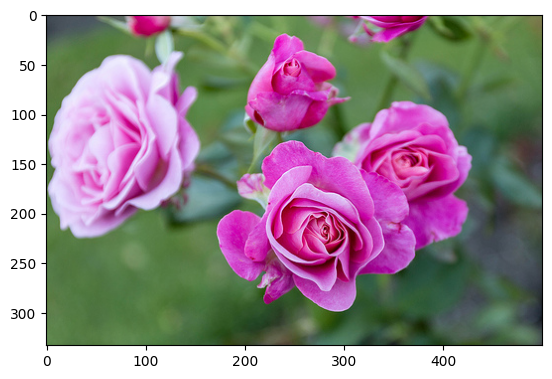

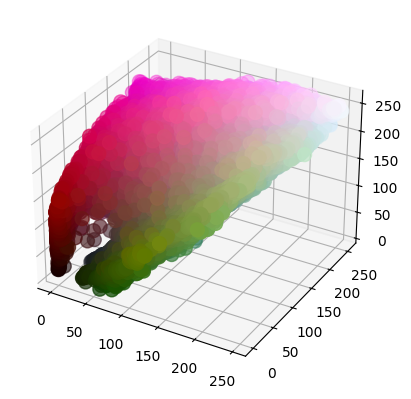

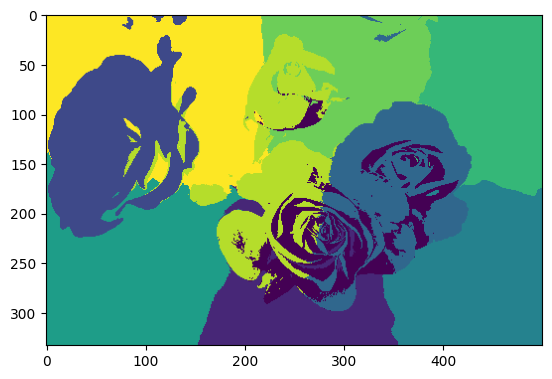





FIltered with sigma 1


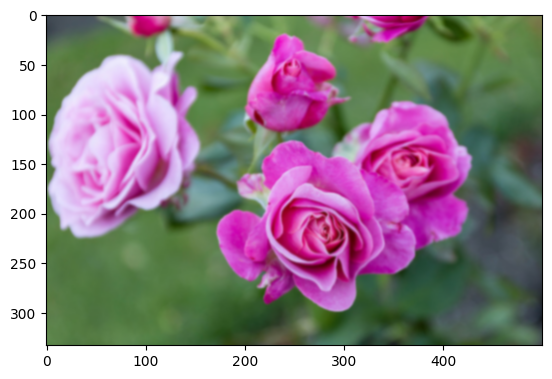

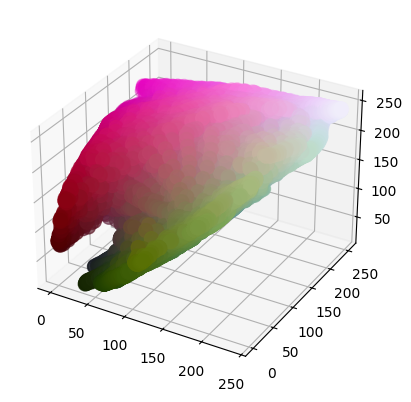

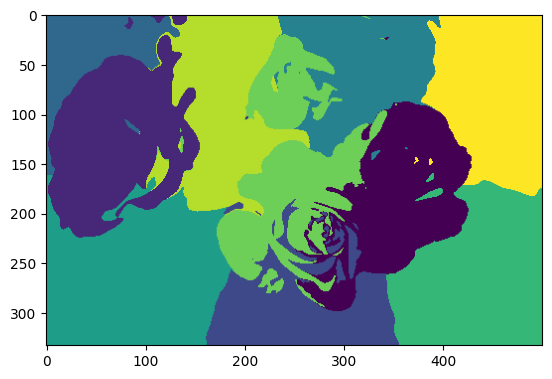





FIltered with sigma 5


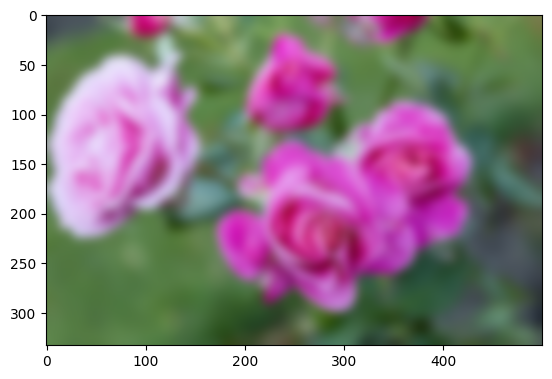

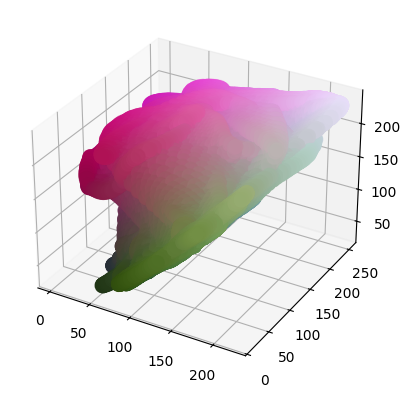

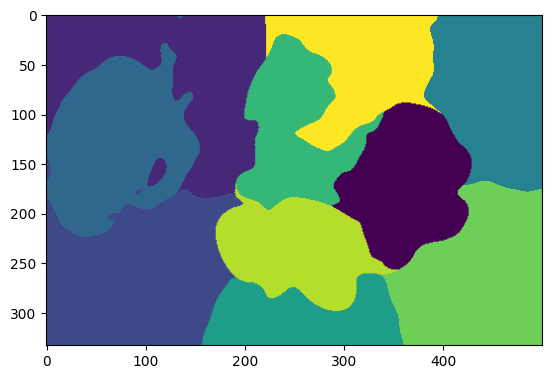





FIltered with sigma 10


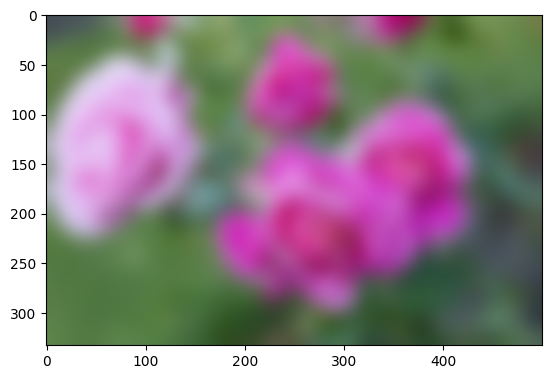

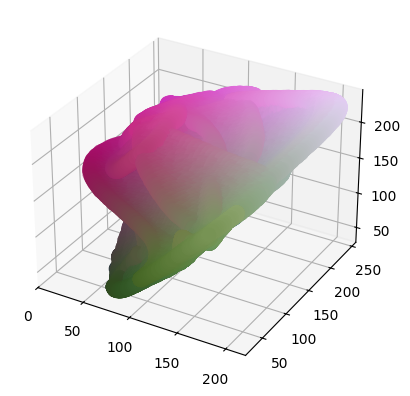

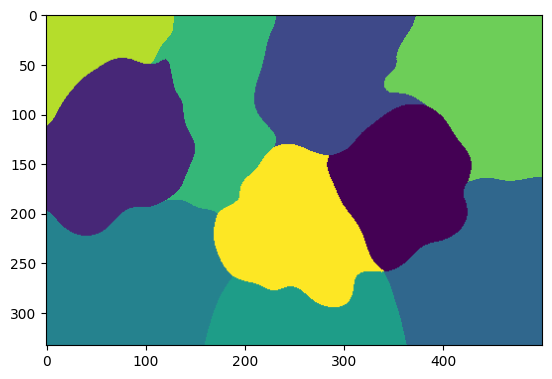

In [8]:
## Lets see it all together:
from scipy.ndimage import gaussian_filter
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

# Give 5 features to the kmeans: r,g,b,x,y when considering several clusters
#indices = np.array(list(np.ndindex(data[:,:,1].shape)))
#np.concatenate([pixel_array, indices], axis=1)

sigmas = [0, 1, 5, 10]
for std in sigmas:
  #data_filtered = gaussian_filter(data, sigma=std)

  for c in [0,1,2]:
    data_filtered[:,:,c] = gaussian_filter(data[:,:,c], sigma=std)

  pixel_array = data_filtered.reshape(data.shape[0]*data.shape[1], 3) 

  #kmeans = KMeans(n_clusters=2, random_state=0).fit(pixel_array)
  kmeans = KMeans(n_clusters=10, random_state=0).fit(np.concatenate([pixel_array, indices], axis=1))
  data_labels = kmeans.labels_

  data_labels = data_labels.reshape(data.shape[0], data.shape[1])

  #### DISPLAY THE PICTURE ####
  print(f'FIltered with sigma {std}')
  fig1 = plt.figure()
  pyplot.imshow(data_filtered)
  pyplot.show()

  #### DISPLAY THE PIXELS ####
  fig2 = plt.figure()
  ax = plt.axes(projection='3d')

  # Data for three-dimensional scattered points
  zdata = pixel_array[:, 0]
  xdata = pixel_array[:, 1]
  ydata = pixel_array[:, 2]
  ax.scatter3D(xdata, ydata, zdata, s=100, facecolor=pixel_array/255);

  #### DISPLAY THE LABEL ####
  fig3 = plt.figure()
  pyplot.imshow(data_labels/data_labels.max()*255)
  pyplot.show()

  print('\n\n\n')

## Segmentation

### Segmentation with Otsu's Thresholding

Another classical segmentation technique: **thresholding** — converting a grayscale image into a binary (black & white) mask by picking a cutoff value. Pixels above the threshold become white (foreground), below become black (background).

**Otsu's method** automates the threshold selection. Instead of guessing a value, it analyses the pixel intensity histogram and finds the threshold that **minimises the variance within each class** (foreground vs background). It works well when the image has two clearly distinct intensity groups.

The steps here are:
1. **`cv2.cvtColor(..., COLOR_BGR2GRAY)`** — convert the colour image to grayscale (single channel)
2. **`cv2.threshold(..., THRESH_BINARY_INV + THRESH_OTSU)`** — apply Otsu's algorithm to find the optimal threshold automatically, then invert the result so the flowers appear white on a black background

The output `thresh` is a binary mask that can be used to isolate the foreground object before extracting features.


libpng warning: iCCP: known incorrect sRGB profile


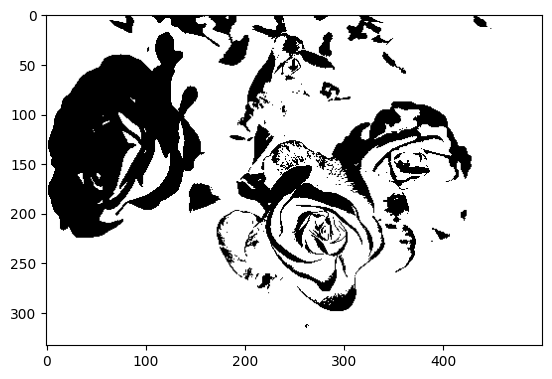

In [9]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('data/Flowers for image classification.png')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')
plt.show()

<br>

## Feature Extraction

### From Pixels to a Feature Vector — the Classical ML Pipeline

The goal of feature extraction is to **convert an image into a row of numbers** that a classical ML model (Random Forest, SVM, etc.) can learn from. Raw pixels are too high-dimensional and unstructured to be fed directly into a classifier — they need to be summarised into meaningful, compact descriptors first.

A common pipeline would look like this:


Raw image
- → Preprocessing       (Gaussian blur to reduce noise)
- → Segmentation        (K-Means assigns each pixel a cluster label)
- → Feature Extraction  (summarise each cluster with statistics)
- → Feature vector      (one row of numbers per image / region)
- → Classical ML model  (Random Forest, SVM, ...) → prediction


In the code below, we first build a flat table where each row is one pixel with 6 columns:

| Column | Description |
|--------|-------------|
| R, G, B | Pixel colour values |
| x, y | Pixel position in the image |
| Label | K-Means cluster the pixel belongs to |

We then `groupby` cluster label to compute **per-region statistics** — these aggregated numbers form the feature vector that gets passed to the classifier:

| Statistic | What it captures |
|-----------|-----------------|
| Count (size) | Region area in pixels |
| Mean R/G/B | Average colour of the region |
| Std R/G/B | Colour uniformity within the region |
| Min/max x, y | Spatial bounding box of the region |

In practice, this process is repeated for every image in the training set. Each image produces one feature vector (one row), and the collection of those rows forms the training dataset for the classifier.

> **Note:** No raw pixels ever reach the model — only the hand-crafted statistics chosen by the engineer. This is the fundamental limitation that CNNs overcome by learning the feature representation directly from data.


In [37]:
import pandas as pd

# Give 5 features to the kmeans: r,g,b,x,y when considering several clusters
indices = np.array(list(np.ndindex(data[:,:,1].shape)))


data_labels = kmeans.labels_ # shaped like (100000, 1) again
data_labels = data_labels.reshape(data_labels.shape[0], 1)
data_labels.shape

features = np.concatenate([pixel_array, indices, data_labels], axis=1)
features.shape
features

features = pd.DataFrame(data=features, columns = ['R', 'G', 'B','x', 'y', 'Label'])
features.head()

,R,G,B,x,y,Label
0,67,76,84,0,0,1
1,67,76,84,0,1,1
2,67,76,84,0,2,1
3,67,76,84,0,3,1
4,67,77,85,0,4,1


In [38]:
# Now it is a matter of being creative...

# SIZE
features.groupby(['Label'], as_index=True)[['R']].count()

# Mean color
features.groupby(['Label'], as_index=True)[['R', 'G', 'B']].mean()

# Mean std
features.groupby(['Label'], as_index=True)[['R', 'G', 'B']].std()

# MAX x and Y
features.groupby(['Label'], as_index=True)[['x', 'y']].agg(['max', 'min'])

# and many more! we could do:
#     -> avg distance between all the pixels
#     -> how close is it to a circle
#     -> etc etc etc 

x        y    
       max min  max min
Label                  
0      295   0  427   0
1      332   0  499   0

<br>

---

<br>

# Practical example of a DNN

In [ ]:
import tensorflow as tf

import os
import numpy as np
import keras
from keras import layers
from keras import ops
import matplotlib.pyplot as plt
import plotly.express as px

In [14]:
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()

In [15]:
num = 10
images = X_train[:num]
labels = Y_train[:num]

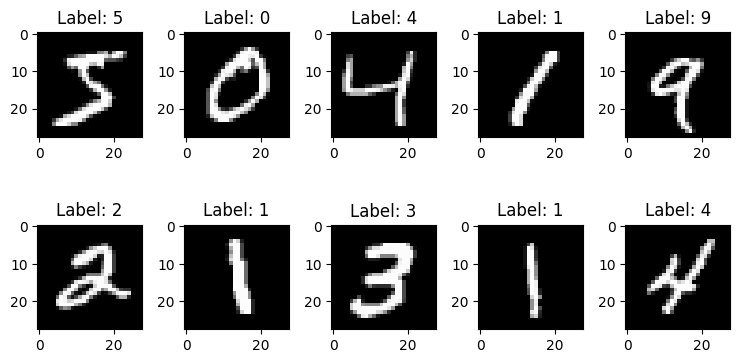

In [16]:
num_row = 2
num_col = 5

# plot images
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title('Label: {}'.format(labels[i]))
plt.tight_layout()
plt.show()

In [39]:
# Function return digit in grayscale
def plot_digit(digit, dem = 28, font_size = 12):
    max_ax = font_size * dem

    fig = plt.figure(figsize=(13, 13))
    plt.xlim([0, max_ax])
    plt.ylim([0, max_ax])
    plt.axis('off')
    black = '#000000'

    for idx in range(dem):
        for jdx in range(dem):

            t = plt.text(idx * font_size, max_ax - jdx*font_size, digit[jdx][idx], fontsize = font_size, color = black)
            c = digit[jdx][idx] / 255.
            t.set_bbox(dict(facecolor=(c, c, c), alpha = 0.5, edgecolor = 'black'))

    plt.show()

5


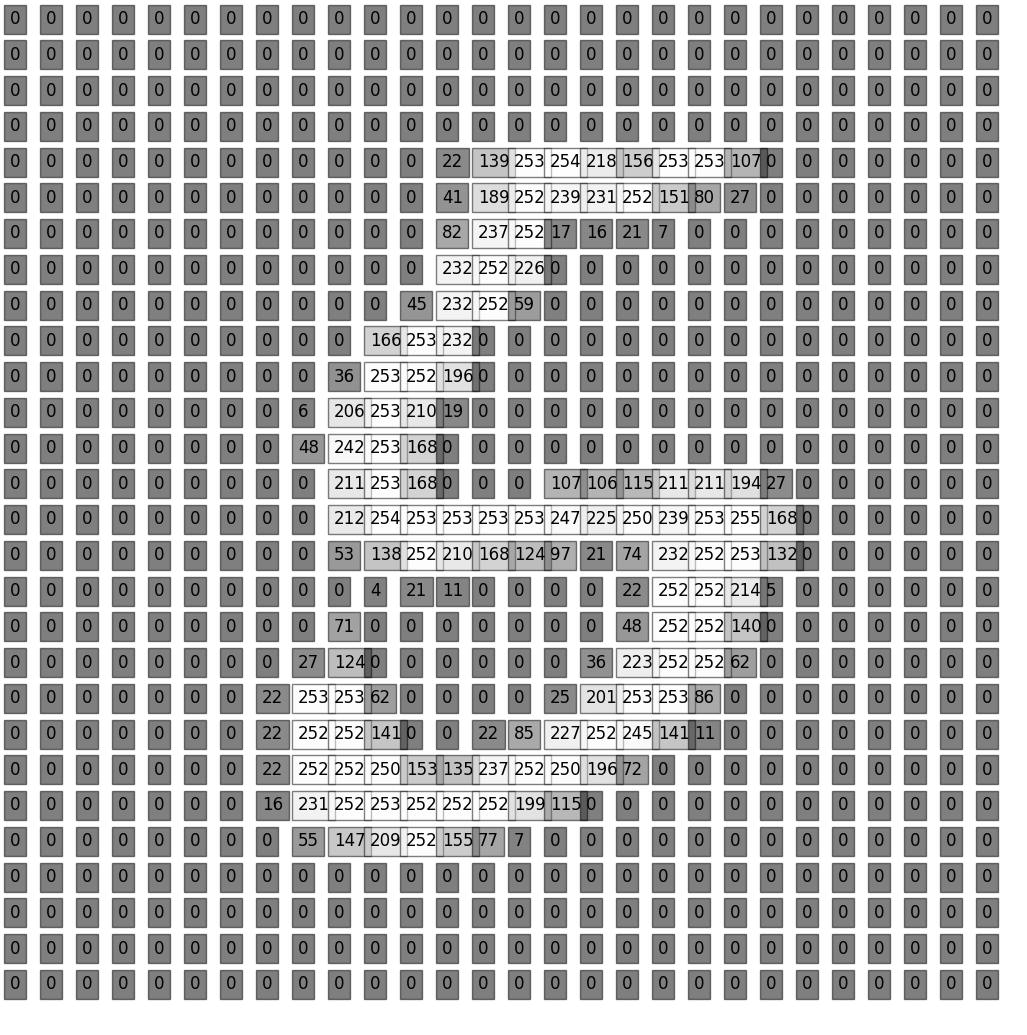

In [43]:
rand_number = np.random.randint(0, len(Y_train))
print(Y_train[rand_number])
plot_digit(X_train.reshape(-1, 28, 28)[rand_number])

In [19]:
inputs = keras.Input(shape=(784,), name="digits") #28*28
x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
x = layers.Dense(64, activation="relu", name="dense_2")(x)
outputs = layers.Dense(10, activation="softmax", name="predictions")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

Here's what the typical end-to-end workflow looks like, consisting of:

- Training
- Validation on a holdout set generated from the original training data
- Evaluation on the test data

In [20]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess the data (these are NumPy arrays)
x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test = x_test.reshape(10000, 784).astype("float32") / 255

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

# Reserve 10,000 samples for validation
x_val = x_train[-10000:]
y_val = y_train[-10000:]
x_train = x_train[:-10000]
y_train = y_train[:-10000]

We specify the training configuration (optimizer, loss, metrics):

In [21]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

We call `fit()`, which will train the model by slicing the data into "batches" of size
`batch_size`, and repeatedly iterating over the entire dataset for a given number of
`epochs`.

In [22]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    # We pass some validation for
    # monitoring validation loss and metrics
    # at the end of each epoch
    validation_data=(x_val, y_val),
)

Fit model on training data
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 623us/step - loss: 0.5766 - sparse_categorical_accuracy: 0.8368 - val_loss: 0.1773 - val_sparse_categorical_accuracy: 0.9485
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 0.1656 - sparse_categorical_accuracy: 0.9499 - val_loss: 0.1260 - val_sparse_categorical_accuracy: 0.9647
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - loss: 0.1156 - sparse_categorical_accuracy: 0.9652 - val_loss: 0.1139 - val_sparse_categorical_accuracy: 0.9687
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 0.0887 - sparse_categorical_accuracy: 0.9739 - val_loss: 0.1029 - val_sparse_categorical_accuracy: 0.9704
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 0.0734 - sparse_categorical_accuracy: 0.9780 - val_loss: 0.0987 - val_sparse_categorical_accuracy: 0.9718
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - loss: 0.0668 - sparse_categorical_accuracy: 0.9799 - val_loss: 0.1021 - val_s

The returned `history` object holds a record of the loss values and metric values
during training:

In [23]:
print(history.history)

{'loss': [0.3411371111869812, 0.15638788044452667, 0.11459746211767197, 0.09086617827415466, 0.07436864078044891, 0.06307931989431381, 0.05462490767240524, 0.046970389783382416, 0.04126114398241043, 0.036676522344350815], 'sparse_categorical_accuracy': [0.9022200107574463, 0.9533799886703491, 0.9657800197601318, 0.972540020942688, 0.9777200222015381, 0.9813799858093262, 0.9832599759101868, 0.9861599802970886, 0.9873999953269958, 0.989080011844635], 'val_loss': [0.17731235921382904, 0.12601231038570404, 0.11392917484045029, 0.10288403183221817, 0.09871608018875122, 0.10206512361764908, 0.09350262582302094, 0.11036829650402069, 0.09801212698221207, 0.1032124012708664], 'val_sparse_categorical_accuracy': [0.9484999775886536, 0.9646999835968018, 0.9686999917030334, 0.9703999757766724, 0.9718000292778015, 0.9718000292778015, 0.9745000004768372, 0.9703999757766724, 0.9728999733924866, 0.9751999974250793]}


We evaluate the model on the test data via `evaluate()`:

In [24]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(x_test, y_test, batch_size=128)
print("test loss, test acc:", results)

# Generate predictions (probabilities -- the output of the last layer)
# on new data using `predict`
print("Generate predictions for 3 samples")
predictions = model.predict(x_test[:3])
print("predictions shape:", predictions.shape)

Evaluate on test data


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - loss: 0.1025 - sparse_categorical_accuracy: 0.9715
test loss, test acc: [0.08855811506509781, 0.9757999777793884]
Generate predictions for 3 samples
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
predictions shape: (3, 10)
